<a href="https://colab.research.google.com/github/matt-ritton/ts.ethanol-production/blob/main/ethanol-production.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💻 About this notebook

This academic-oriented notebook was created to analyze historical series of ethanol production in the state of Minas Gerais - BR. The objective is to propose and justify a suitable model for ethanol production forecasts.

The data were obtained from the National Agency of Petroleum, Natural Gas and Biofuels (ANP), through the Brazilian Federal Government's open-data portal. The series covers monthly total ethanol production in Minas Gerais, in cubic meters, from January 2012 to April 2026.

Data: https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-estatisticos/de/pb/

**PS:** Since the goal is to characterize behavior over complete calendar years, the series was truncated at December 2025, totaling 168 observations.

### 💬 What will be discussed here?
The notebook is divided into sections based on a time series analysis to solve a production prediction problem. I tried to make it as didactic as possible for understanding.

In [ ]:
# Necessary libraries
!pip install pmdarima

import numpy as np
import pmdarima as pm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import itertools
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from pmdarima.arima.seasonality import OCSBTest
from pmdarima.arima.utils import nsdiffs
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.ar_model import ar_select_order
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import warnings

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 12.7 MB/s eta 0:00:00


In [ ]:
# Dataset
!wget -O ETHANOL.csv https://raw.githubusercontent.com/matt-ritton/ts.ethanol-production/refs/heads/main/ETHANOL.csv

--2026-06-05 13:03:02--  https://raw.githubusercontent.com/matt-ritton/ts.ethanol-production/refs/heads/main/ETHANOL.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2996 (2.9K) [text/plain]
Saving to: ‘ETHANOL.csv’

ETHANOL.csv         100%[===================>]   2.93K  --.-KB/s    in 0s      

2026-06-05 13:03:02 (32.9 MB/s) - ‘ETHANOL.csv’ saved [2996/2996]



In [ ]:
# ------------------------------------------------------------
# Plot Styles
# ------------------------------------------------------------

# Seaborn Theme
sns.set_theme(style="whitegrid", context="notebook")

title_style = {"fontweight": "semibold","pad": 12}
label_style = {"fontsize": 10,"fontweight": "semibold", "labelpad": 12}
tick_style = {"labelsize": 9, "labelcolor": "#606060"}
grid_style = {"linestyle": "-", "linewidth": 0.7, "alpha": 0.35}

In [ ]:
# ------------------------------------------------------------
# Data preparation
# ------------------------------------------------------------

df = pd.read_csv('ETHANOL.csv', parse_dates=['Date'])

# Set the date as the dataset index
df = df.set_index('Date').sort_index()
df.index.freq = 'MS'

serie = df['Production'].astype(float)

# Drop 2026 months
serie = serie[serie.index <= '2025-12-01']

# ------------------------------------------------------------
# Time Series Info
# ------------------------------------------------------------

print(f"Minas Gerais Ethanol Production")
print(f"Initial date: {serie.index.min().strftime('%Y-%m')}")
print(f"Final date: {serie.index.max().strftime('%Y-%m')}")
print(f"Number of observations: {serie.shape[0]}")
print(f"Number of missing values: {serie.isna().sum()}")

Minas Gerais Ethanol Production
Initial date: 2012-01
Final date: 2025-12
Number of observations: 168
Number of missing values: 0


# 🔍 Exploratory Time Series Analysis

This section describes the series before any modeling. We start with descriptive statistics and a line plot of the full series, then characterize the seasonal behavior through monthly boxplots, a year-over-year view, and a heatmap.

In [ ]:
# ------------------------------------------------------------
# Descriptive Statistics (training set)
# ------------------------------------------------------------

summary_statistics = pd.DataFrame({
    "Mean": [serie.mean()],
    "Median": [serie.median()],
    "Standard deviation": [serie.std()],
    "Minimum": [serie.min()],
    "Maximum": [serie.max()],
    "Missing values": [serie.isna().sum()]
})

summary_statistics

,Mean,Median,Standard deviation,Minimum,Maximum,Missing values
0,245912.380952,257776.5,188436.232459,0.0,574332.0,0


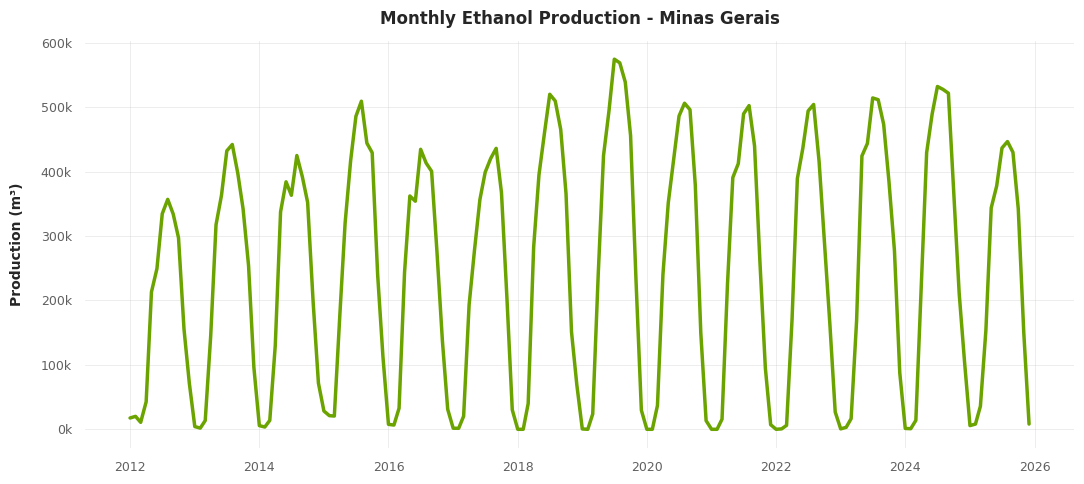

In [ ]:
# ------------------------------------------------------------
# Time Series Visualization
# ------------------------------------------------------------

# Plotting
fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(x=serie.index, y=serie.values, ax=ax, linewidth=2.5, color="#6BA300")

## Title
ax.set_title(f"Monthly Ethanol Production - Minas Gerais", **title_style)

## Axes Labels
ax.set_xlabel("")
ax.set_ylabel("Production (m³)", **label_style)

## Axes ticks
ax.tick_params(axis='both', which="both", **tick_style)

## Y axis formatter
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

## Hide unnecessary edges
for spine in ax.spines.values():
    spine.set_visible(False)

## Grid
ax.grid( True, which="major", **grid_style)

plt.tight_layout()
plt.show()

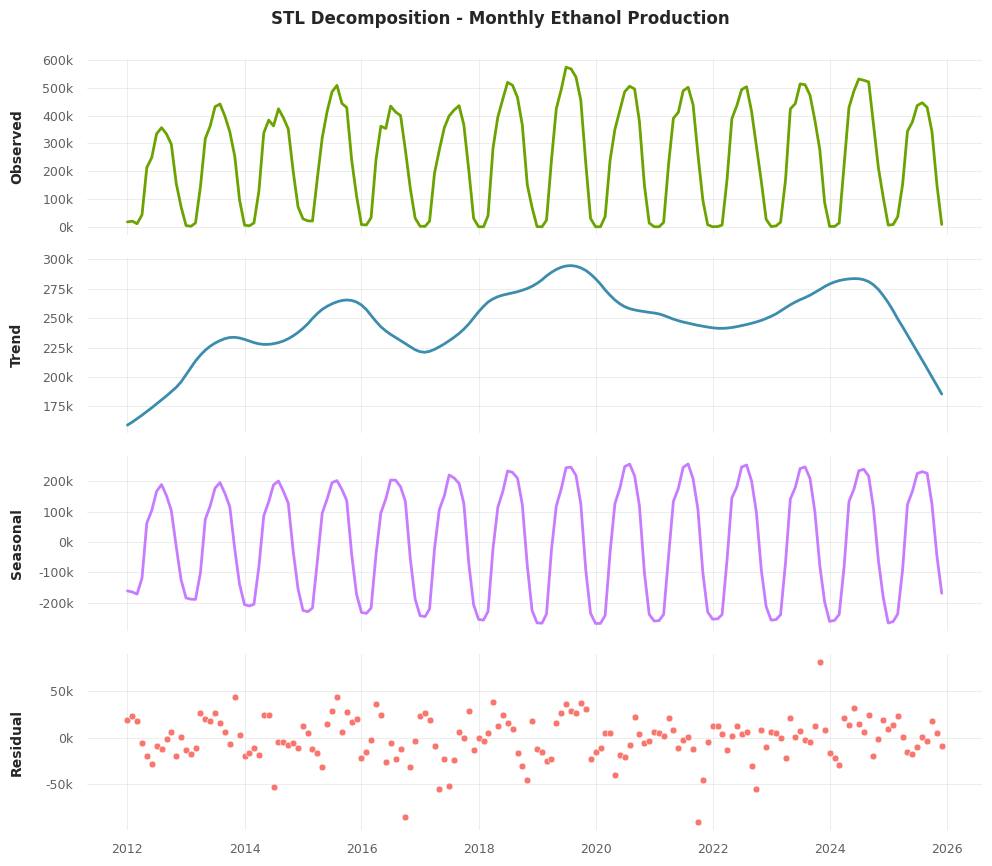

In [ ]:
# ------------------------------------------------------------
# Time Series Decomposition
# ------------------------------------------------------------
stl = STL(serie, period=12, robust=True)
res = stl.fit()

# Plotting decomposition
observed = serie
trend = res.trend
seasonal = res.seasonal
residual = res.resid

fig, axes = plt.subplots(4, 1,figsize=(10, 9),sharex=True)

component_data = [
    (observed, "Observed", "#6BA300"),
    (trend, "Trend", "#3C8DAD"),
    (seasonal, "Seasonal", "#C77CFF"),
    (residual, "Residual", "#F8766D")
]

for ax, (series, label, color) in zip(axes, component_data):

    if label == "Residual":
      sns.scatterplot(x=series.index, y=series.values, ax=ax, color=color, s=24)
    else:
      sns.lineplot(x=series.index, y=series.values, ax=ax, linewidth=2.0, color=color)

    fig.suptitle(f"STL Decomposition - Monthly Ethanol Production", fontsize=12, fontweight="semibold", y=0.96)

    ax.set_ylabel(label, **label_style)
    ax.yaxis.set_label_coords(-0.07, 0.5)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

    ax.grid(True, which="major", **grid_style)

    ax.tick_params(axis='both', which="both", **tick_style)

    for spine in ax.spines.values():
          spine.set_visible(False)

## Hide X axis label in upper panels
for ax in axes[:-1]:
    ax.set_xlabel("")

axes[-1].set_xlabel("")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## ♻ Seasonal Behavior

To inspect the annual pattern we look at the distribution of production by month and by year. The monthly boxplots expose the harvest calendar directly; the yearly boxplots and the heatmap show how the overall level evolves across years and how stable the seasonal shape is over time.

In [ ]:
# Seasonal serie
seasonal_df = serie.to_frame(name="Production")
seasonal_df["Month"] = seasonal_df.index.month
seasonal_df["Year"] = seasonal_df.index.year

# Seasonal serie (Last X available years)
last_n_years = 7
recent_years = sorted(seasonal_df["Year"].unique())[-last_n_years:]
recent_seasonal_df = seasonal_df[seasonal_df["Year"].isin(recent_years)].copy()

# Labels for monthly charts
month_labels = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

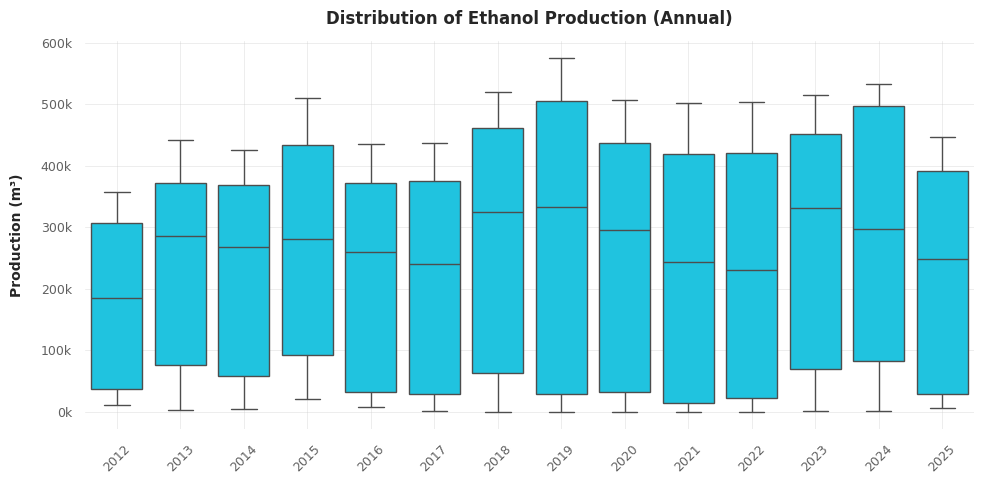

In [ ]:
# ------------------------------------------------------------
# Boxplot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(data=seasonal_df, x="Year", y="Production", ax=ax, color="#00D9FF")

ax.set_title(f"Distribution of Ethanol Production (Annual)", **title_style)

ax.set_xlabel("")
ax.set_ylabel("Production (m³)", **label_style)

ax.tick_params(axis="x", which="both", **tick_style, rotation=45)
ax.tick_params(axis="y", which="both", **tick_style)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

for spine in ax.spines.values():
      spine.set_visible(False)

ax.grid(True, which="major", **grid_style)

plt.tight_layout()
plt.show()

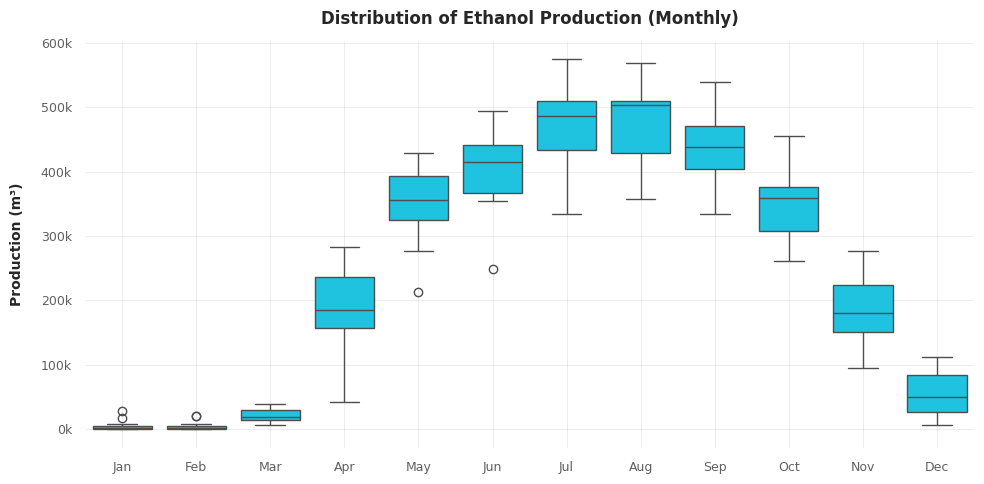

In [ ]:
# ------------------------------------------------------------
# Monthly Boxplot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(data=seasonal_df, x="Month", y="Production", ax=ax, color="#00D9FF")

ax.set_title(f"Distribution of Ethanol Production (Monthly)", **title_style)

ax.set_xlabel("", **label_style)
ax.set_ylabel("Production (m³)", **label_style)

ax.set_xticks(range(12))
ax.set_xticklabels(month_labels)

ax.tick_params(axis='both', which="both", **tick_style)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

for spine in ax.spines.values():
      spine.set_visible(False)

ax.grid(True, which="major", **grid_style)

plt.tight_layout()
plt.show()

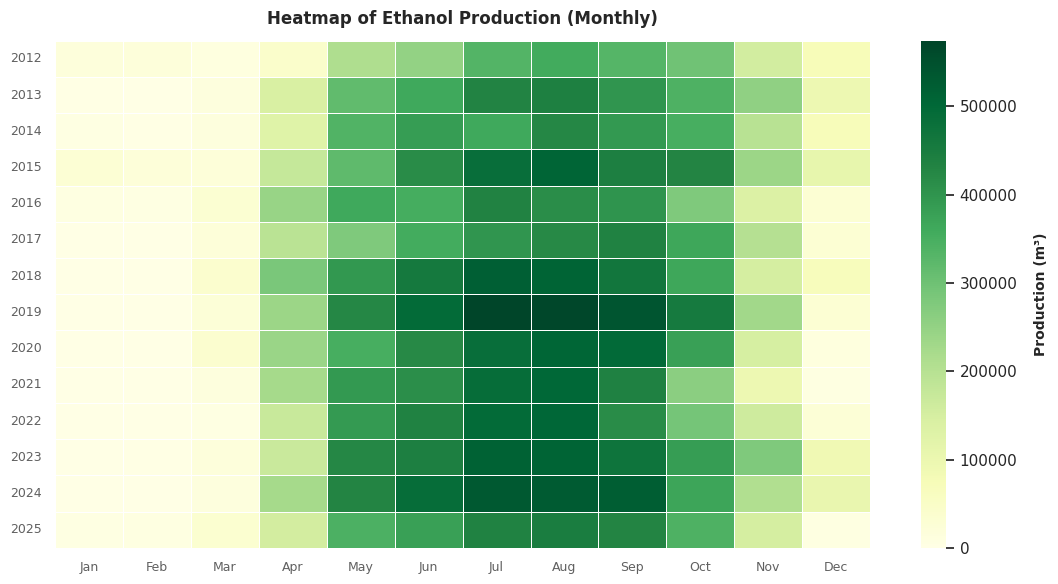

In [ ]:
# ------------------------------------------------------------
# Heatmap
# ------------------------------------------------------------

heatmap_data = seasonal_df.pivot_table(index="Year", columns="Month", values="Production")

fig, ax = plt.subplots(figsize=(11, 6))

sns.heatmap(heatmap_data, cmap="YlGn", linewidths=0.5, linecolor="white", cbar_kws={"label": "Production (m³)"},ax=ax)
cbar = ax.figure.axes[-1]
cbar.set_ylabel("Production (m³)", **label_style)

ax.set_title(f"Heatmap of Ethanol Production (Monthly)", **title_style)

ax.set_xlabel("", **label_style)
ax.set_ylabel("", **label_style)

ax.set_xticklabels(month_labels, rotation=0)

ax.tick_params(axis='both', which="both", **tick_style)

ax.grid(True, which="major", **grid_style)

plt.tight_layout()
plt.show()

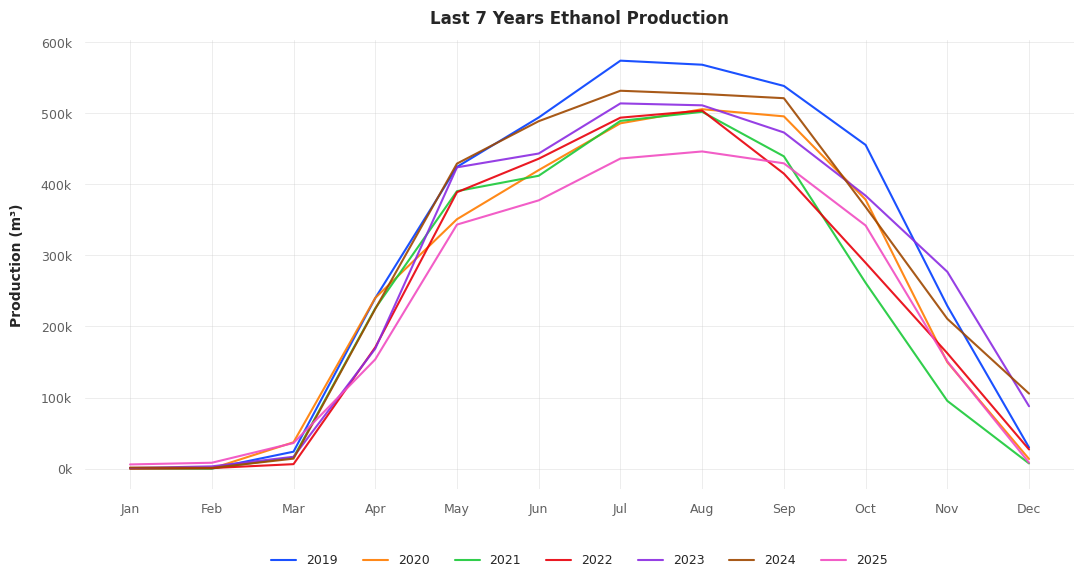

In [ ]:
# ------------------------------------------------------------
# Seasonal subseries plot (Last 7 years)
# ------------------------------------------------------------

years = sorted(seasonal_df["Year"].unique())
palette = sns.color_palette("bright", n_colors=len(years))

fig, ax = plt.subplots(figsize=(11, 6))

for color, (year, group) in zip(palette, recent_seasonal_df.groupby("Year")):
    sns.lineplot(x=group["Month"], y=group["Production"], ax=ax, linewidth=1.5, alpha=0.9, label=year, color=color)

ax.set_title(f"Last {last_n_years} Years Ethanol Production", **title_style)

ax.set_xlabel("", **label_style)
ax.set_ylabel("Production (m³)", **label_style)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)

ax.tick_params(axis='both', which="both", **tick_style)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

for spine in ax.spines.values():
      spine.set_visible(False)

ax.grid(True, which="major", **grid_style)

ax.legend(bbox_to_anchor=(0.5, -0.12), loc="upper center", ncol=last_n_years, frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

## Exploratory Analysis Discussion

The line plot already reveals the two defining features of this series: a strong, repeating annual cycle and a mild upward drift in the overall level.

The Seasonal Behavior confirms a strong, stable annual cycle driven by the sugarcane calendar. Production is minimal between January and March (off-season), rises sharply from April, and peaks between July and September (full harvest), before declining toward December. The monthly boxplots show that this shape repeats every year with little change in timing.

Two points stand out for modeling. First, the off-season months fall close to zero — some years record no production at all — which makes a purely multiplicative treatment impractical. Second, the amplitude of the seasonal swing grows together with the overall level across the years, i.e. the cycle is wider in high-production years; this scaling of the seasonal range with the level is the signature of a multiplicative-type seasonality, even though the zeros prevent us from modeling it that way directly.

In [ ]:
# ------------------------------------------------------------
# Train-test split
# ------------------------------------------------------------

forecast_horizon = 12

train = serie.iloc[:-forecast_horizon]
test = serie.iloc[-forecast_horizon:]

# 📈 Stationarity Analysis

This section checks for stationarity at two levels. For the *regular* component we apply two complementary unit-root tests: the Augmented Dickey-Fuller (ADF), whose null hypothesis is the presence of a unit root (non-stationarity), and the KPSS test, whose null is stationarity. Using both guards against the limited power of either test in isolation.

For the *seasonal* component we apply the Osborn-Chui-Smith-Birchenhall (OCSB) test, which estimates whether a seasonal difference is required. We then read the ACF and PACF to anticipate the autoregressive and moving-average orders before formal model selection.

In [ ]:
# ------------------------------------------------------------
# Augmented Dickey-Fuller Test
# ------------------------------------------------------------
adf_result = adfuller(train.dropna())

adf_output = pd.Series(
    {
        "ADF statistic": adf_result[0],
        "p-value": adf_result[1],
        "Number of lags used": adf_result[2],
        "Number of observations": adf_result[3],
        "Critical value 1%": adf_result[4]["1%"],
        "Critical value 5%": adf_result[4]["5%"],
        "Critical value 10%": adf_result[4]["10%"]
    }
)

adf_output

,0
ADF statistic,-2.775145
p-value,0.061913
Number of lags used,12.000000
Number of observations,143.000000
Critical value 1%,-3.476927
Critical value 5%,-2.881973
Critical value 10%,-2.577665


In [ ]:
alpha = 0.05

if adf_result[1] <= alpha:
    print("Reject H0: the series is likely stationary according to the ADF test.")
else:
    print("Fail to reject H0: the series is likely non-stationary according to the ADF test.")

Fail to reject H0: the series is likely non-stationary according to the ADF test.


In [ ]:
# ------------------------------------------------------------
# KPSS test
# ------------------------------------------------------------

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    kpss_result = kpss(
        train.dropna(),
        regression="c",
        nlags="auto"
    )

kpss_output = pd.Series(
    {
        "KPSS statistic": kpss_result[0],
        "p-value": kpss_result[1],
        "Number of lags used": kpss_result[2],
        "Critical value 10%": kpss_result[3]["10%"],
        "Critical value 5%": kpss_result[3]["5%"],
        "Critical value 2.5%": kpss_result[3]["2.5%"],
        "Critical value 1%": kpss_result[3]["1%"]
    }
)

kpss_output

,0
KPSS statistic,0.142333
p-value,0.100000
Number of lags used,6.000000
Critical value 10%,0.347000
Critical value 5%,0.463000
Critical value 2.5%,0.574000
Critical value 1%,0.739000


In [ ]:
alpha = 0.05

if kpss_result[1] <= alpha:
    print("Reject H0: the series is likely non-stationary according to the KPSS test.")
else:
    print("Fail to reject H0: the series is likely stationary according to the KPSS test.")

Fail to reject H0: the series is likely stationary according to the KPSS test.


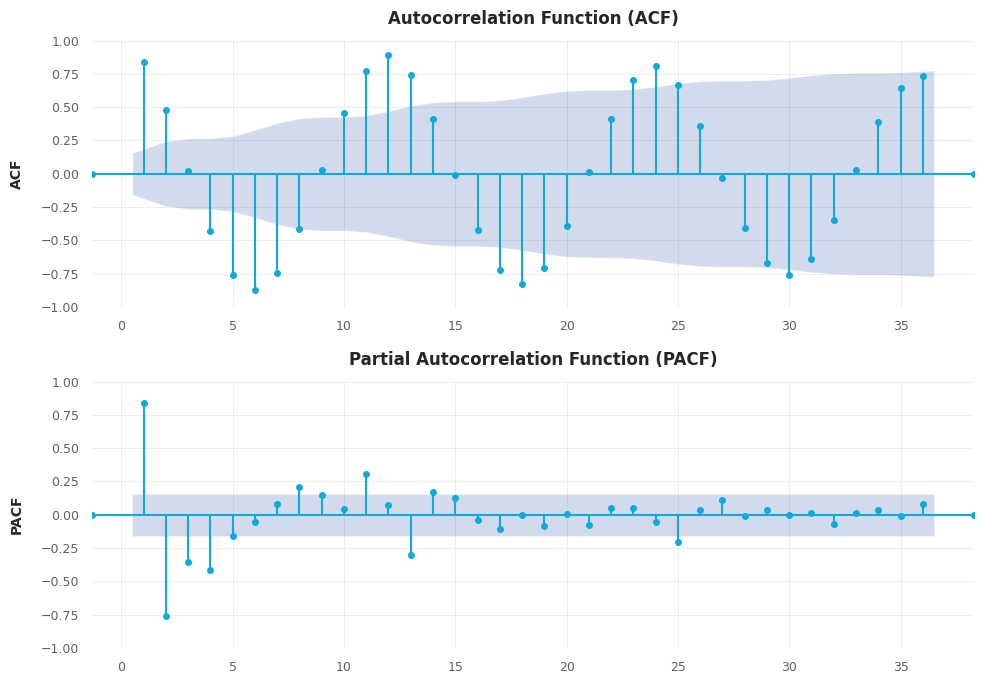

In [ ]:
# ------------------------------------------------------------
# Plot ACF and PACF
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(10, 7))

plot_acf(train, lags=36, ax=axes[0], alpha=0.05, zero=False, title="", marker="o", markersize=4, color="#0EAADA", vlines_kwargs={"colors": "#0EAADA", "linewidth": 1.5})
plot_pacf(train, lags=36, ax=axes[1], alpha=0.05, zero=False, method="ywm", title="", marker="o", markersize=4, color="#0EAADA", vlines_kwargs={"colors": "#0EAADA", "linewidth": 1.5})

axes[0].set_title("Autocorrelation Function (ACF)", **title_style)
axes[0].set_ylabel("ACF", **label_style)

axes[1].set_title("Partial Autocorrelation Function (PACF)", **title_style)
axes[1].set_ylabel("PACF", **label_style)

for ax in axes:
    ax.tick_params(axis='both', which="both", **tick_style)

    ax.grid(True, which="major", **grid_style)

    for spine in ax.spines.values():
      spine.set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# OCSB test (seasonal differencing order)
# ------------------------------------------------------------

ocsb_test = OCSBTest(m=12)
D_ocsb = ocsb_test.estimate_seasonal_differencing_term(train.dropna())

ocsb_output = pd.Series(
    {
        "Seasonal period (m)": ocsb_test.m,
        "Lag selection method": ocsb_test.lag_method,
        "Max lag": ocsb_test.max_lag,
        "Seasonal differences (D)": D_ocsb
    }
)

ocsb_output

,0
Seasonal period (m),12
Lag selection method,aic
Max lag,3
Seasonal differences (D),1


In [ ]:
# Seasonal difference (D=1, s=12)
seasonal_diff = train.diff(12).dropna()

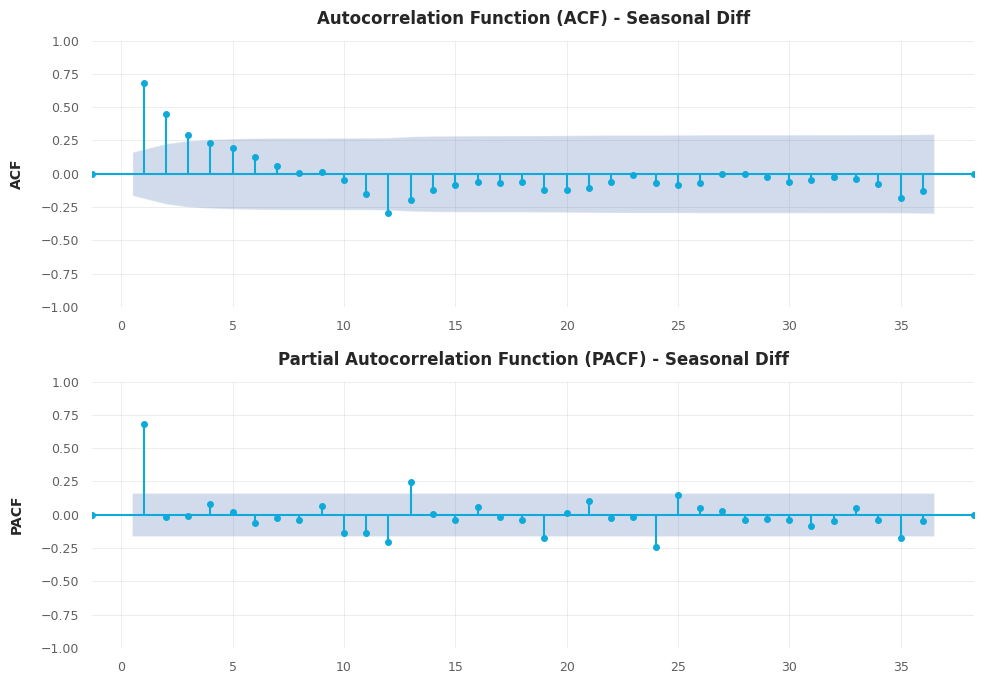

In [ ]:
# ------------------------------------------------------------
# Plot ACF and PACF (Seasonally Differenced)
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(10, 7))

plot_acf(seasonal_diff, lags=36, ax=axes[0], alpha=0.05, zero=False, title="", marker="o", markersize=4, color="#0EAADA", vlines_kwargs={"colors": "#0EAADA", "linewidth": 1.5})
plot_pacf(seasonal_diff, lags=36, ax=axes[1], alpha=0.05, zero=False, method="ywm", title="", marker="o", markersize=4, color="#0EAADA", vlines_kwargs={"colors": "#0EAADA", "linewidth": 1.5})

axes[0].set_title("Autocorrelation Function (ACF) - Seasonal Diff", **title_style)
axes[0].set_ylabel("ACF", **label_style)

axes[1].set_title("Partial Autocorrelation Function (PACF) - Seasonal Diff", **title_style)
axes[1].set_ylabel("PACF", **label_style)

for ax in axes:
    ax.tick_params(axis='both', which="both", **tick_style)

    ax.grid(True, which="major", **grid_style)

    for spine in ax.spines.values():
      spine.set_visible(False)

plt.tight_layout()
plt.show()

### Autocorrelation and Partial Autocorrelation Analysis

The ADF and KPSS tests on the level series are inconclusive regarding a *regular* unit root: the ADF p-value sits near the 5% threshold while KPSS does not reject stationarity. This ambiguity is expected — both tests target the regular component, whereas the dominant non-stationarity here is **seasonal**. The level ACF makes this clear: it shows a slowly decaying, sinusoidal pattern with peaks at lags 12, 24 and 36, the signature of a seasonal unit root. This motivates a seasonal difference (D = 1), with no regular difference (d = 0).

After the seasonal difference, the structure becomes interpretable:

*   **Non-seasonal lags**: the ACF decays geometrically while the PACF cuts off after lag 1, consistent with a regular AR(1) term.

*   **Seasonal lags**: the ACF shows a single significant peak at lag 12 that does not repeat at 24 or 36, while the PACF tails off across seasonal lags — consistent with a seasonal MA component.

This visual reading is **exploratory**: it characterizes the autocorrelation structure and anticipates the differencing orders, but it does not by itself define the final model. Formal model selection is delegated to `auto_arima`, which performs a stepwise AIC search (selecting d and D via unit-root tests) — the methodology addressed in the next section.

# 👀 Forecasting Models

We now compare forecasting models from three families: exponential smoothing (Holt-Winters), Box-Jenkins (SARIMA), and neural networks (NNAR and MLP). A Seasonal Naïve model — repeating the last observed year — serves as the baseline against which every other model is judged.

All models are fitted on the training set (Jan 2012 – Dec 2024) and evaluated on a 12-month holdout (Jan – Dec 2025). Performance is measured with RMSE, sMAPE, and RelRMSE (RMSE relative to the Seasonal Naïve), so that values below 1 indicate a model that improves on the naive benchmark.

## 🧪 Fitting Models

Each model is fitted below, with configuration choices guided by the exploratory analysis. Holt-Winters uses additive seasonality, since the near-zero off-season values rule out a multiplicative form. SARIMA is selected by a stepwise AIC search (via `auto_arima`), consistent with the differencing orders suggested by the stationarity tests (d = 0, D = 1). NNAR and MLP are autoregressive neural networks that contrast two ways of handling seasonality: NNAR captures it implicitly through a seasonal lag, while MLP receives it explicitly through monthly dummy variables. Each network model is an ensemble of 20 fits aggregated by the mean (NNAR) and median (MLP) to reduce sensitivity to random initialization.

In [ ]:
# ------------------------------------------------------------
# Seasonal Naïve (baseline)
# ------------------------------------------------------------

snaive_forecast = pd.Series(
    train.values[-forecast_horizon:],
    index=test.index,
)
snaive_fitted = pd.Series(train.values[:-12], index=train.index[12:])

In [ ]:
# ------------------------------------------------------------
# Holt-Winters Additive
# ------------------------------------------------------------

hw_model = ExponentialSmoothing(
    train,
    trend=None,
    seasonal='add',
    seasonal_periods=12,
    initialization_method='estimated'
).fit()

hw_fitted = hw_model.fittedvalues
hw_forecast = hw_model.forecast(forecast_horizon).clip(lower=0)

In [ ]:
# ------------------------------------------------------------
# Box-Jenkins SARIMA
# ------------------------------------------------------------

sarima_model = pm.auto_arima(
    train,
    seasonal=True,
    m=12,
    stepwise=True,
    trace=True,
    suppress_warnings=True,
    error_action="ignore",
)

sarima_fitted = pd.Series(sarima_model.predict_in_sample(), index=train.index)
sarima_forecast = pd.Series(
    np.clip(sarima_model.predict(forecast_horizon), 0, None),
    index=test.index,
)

print(f"Selected model: SARIMA{sarima_model.order}{sarima_model.seasonal_order}")
print(f"AIC = {sarima_model.aic():.1f} | BIC = {sarima_model.bic():.1f}")

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=3454.681, Time=2.77 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=3544.037, Time=0.49 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=3452.500, Time=0.49 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=3487.767, Time=0.35 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=3546.811, Time=0.06 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=3459.716, Time=0.08 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=3449.944, Time=1.17 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=3451.742, Time=2.63 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=3451.036, Time=0.69 sec
 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=3545.678, Time=1.91 sec
 ARIMA(2,0,0)(2,1,0)[12] intercept   : AIC=3450.767, Time=2.09 sec
 ARIMA(1,0,1)(2,1,0)[12] intercept   : AIC=3450.653, Time=1.29 sec
 ARIMA(0,0,1)(2,1,0)[12] intercept   : AIC=3487.561, Time=0.84 sec
 ARIMA(2,0,1)(2,1,0)[12] intercept   : AIC=3452.039, Time=2.86 sec
 ARIMA(1,0,0)(2,1,0

In [ ]:
# ------------------------------------------------------------
# NNAR - Neural Network AutoRegression (nnetar-style)
# ------------------------------------------------------------

# Automatic lag selection on the seasonally-adjusted series
stl_fit = STL(train, period=12, robust=True).fit()
ar_selection = ar_select_order(train - stl_fit.seasonal, maxlag=12, ic="aic", old_names=False)
nnar_p = max(ar_selection.ar_lags) if ar_selection.ar_lags else 1

nnar_P, m = 1, 12
nnar_lags = list(range(1, nnar_p + 1)) + [m * k for k in range(1, nnar_P + 1)]
nnar_hidden = round((len(nnar_lags) + 1) / 2)
n_networks = 20

# Lag-matrix builder (reused by the MLP cell)
def build_ar_features(y, lags):
    max_lag = max(lags)
    X = [[y[i - l] for l in lags] for i in range(max_lag, len(y))]
    target = [y[i] for i in range(max_lag, len(y))]
    return np.array(X), np.array(target)

y_train = train.values.astype(float)
X, target = build_ar_features(y_train, nnar_lags)

scaler_X = StandardScaler().fit(X)
scaler_y = StandardScaler().fit(target.reshape(-1, 1))
X_scaled = scaler_X.transform(X)
y_scaled = scaler_y.transform(target.reshape(-1, 1)).ravel()

nnar_fit_preds = np.zeros((n_networks, len(target)))
nnar_fc_preds = np.zeros((n_networks, forecast_horizon))
for n in range(n_networks):
    net = MLPRegressor(hidden_layer_sizes=(nnar_hidden,), activation="logistic",
                       solver="lbfgs", max_iter=2000, random_state=n)
    net.fit(X_scaled, y_scaled)

    nnar_fit_preds[n] = scaler_y.inverse_transform(
        net.predict(X_scaled).reshape(-1, 1)).ravel()

    history = list(y_train)
    for h in range(forecast_horizon):
        feat = scaler_X.transform([[history[-l] for l in nnar_lags]])
        pred = scaler_y.inverse_transform(net.predict(feat).reshape(-1, 1))[0, 0]
        history.append(pred)
        nnar_fc_preds[n, h] = pred

nnar_fitted = pd.Series(np.clip(nnar_fit_preds.mean(axis=0), 0, None),
                        index=train.index[max(nnar_lags):])
nnar_forecast = pd.Series(np.clip(nnar_fc_preds.mean(axis=0), 0, None), index=test.index)

print(f"Model: NNAR({nnar_p},{nnar_P},{nnar_hidden})[{m}]")

Model: NNAR(1,1,2)[12]


In [ ]:
# ------------------------------------------------------------
# MLP - Multilayer Perceptron
# ------------------------------------------------------------

mlp_lags = list(range(1, m + 1))
mlp_hidden = 5

train_months = train.index.month.values

def build_features_seasonal(y, months_idx, lags):
    max_lag = max(lags)
    X, target, mon = [], [], []
    for i in range(max_lag, len(y)):
        X.append([y[i - l] for l in lags])
        target.append(y[i])
        mon.append(months_idx[i])
    return np.array(X), np.array(target), np.array(mon)

X_ar, target_mlp, mon_train = build_features_seasonal(y_train, train_months, mlp_lags)
season_dummies = pd.get_dummies(mon_train, drop_first=True).values.astype(float)
X_mlp = np.hstack([X_ar, season_dummies])

scaler_X_mlp = StandardScaler().fit(X_mlp)
scaler_y_mlp = StandardScaler().fit(target_mlp.reshape(-1, 1))
X_mlp_scaled = scaler_X_mlp.transform(X_mlp)
y_mlp_scaled = scaler_y_mlp.transform(target_mlp.reshape(-1, 1)).ravel()

def month_dummy_vector(month):
    base = pd.Series([month] + list(range(1, 13)))
    return pd.get_dummies(base, drop_first=True).values[0].astype(float)

mlp_fit_preds = np.zeros((n_networks, len(target_mlp)))
mlp_fc_preds = np.zeros((n_networks, forecast_horizon))
for n in range(n_networks):
    net = MLPRegressor(hidden_layer_sizes=(mlp_hidden,), max_iter=3000, random_state=n)
    net.fit(X_mlp_scaled, y_mlp_scaled)

    mlp_fit_preds[n] = scaler_y_mlp.inverse_transform(
        net.predict(X_mlp_scaled).reshape(-1, 1)).ravel()

    history = list(y_train)
    for h in range(forecast_horizon):
        future_month = test.index.month[h]
        feat = [history[-l] for l in mlp_lags] + list(month_dummy_vector(future_month))
        pred = scaler_y_mlp.inverse_transform(
            net.predict(scaler_X_mlp.transform([feat])).reshape(-1, 1))[0, 0]
        history.append(pred)
        mlp_fc_preds[n, h] = pred

mlp_fitted = pd.Series(np.clip(np.median(mlp_fit_preds, axis=0), 0, None),
                       index=train.index[max(mlp_lags):])
mlp_forecast = pd.Series(np.clip(np.median(mlp_fc_preds, axis=0), 0, None), index=test.index)

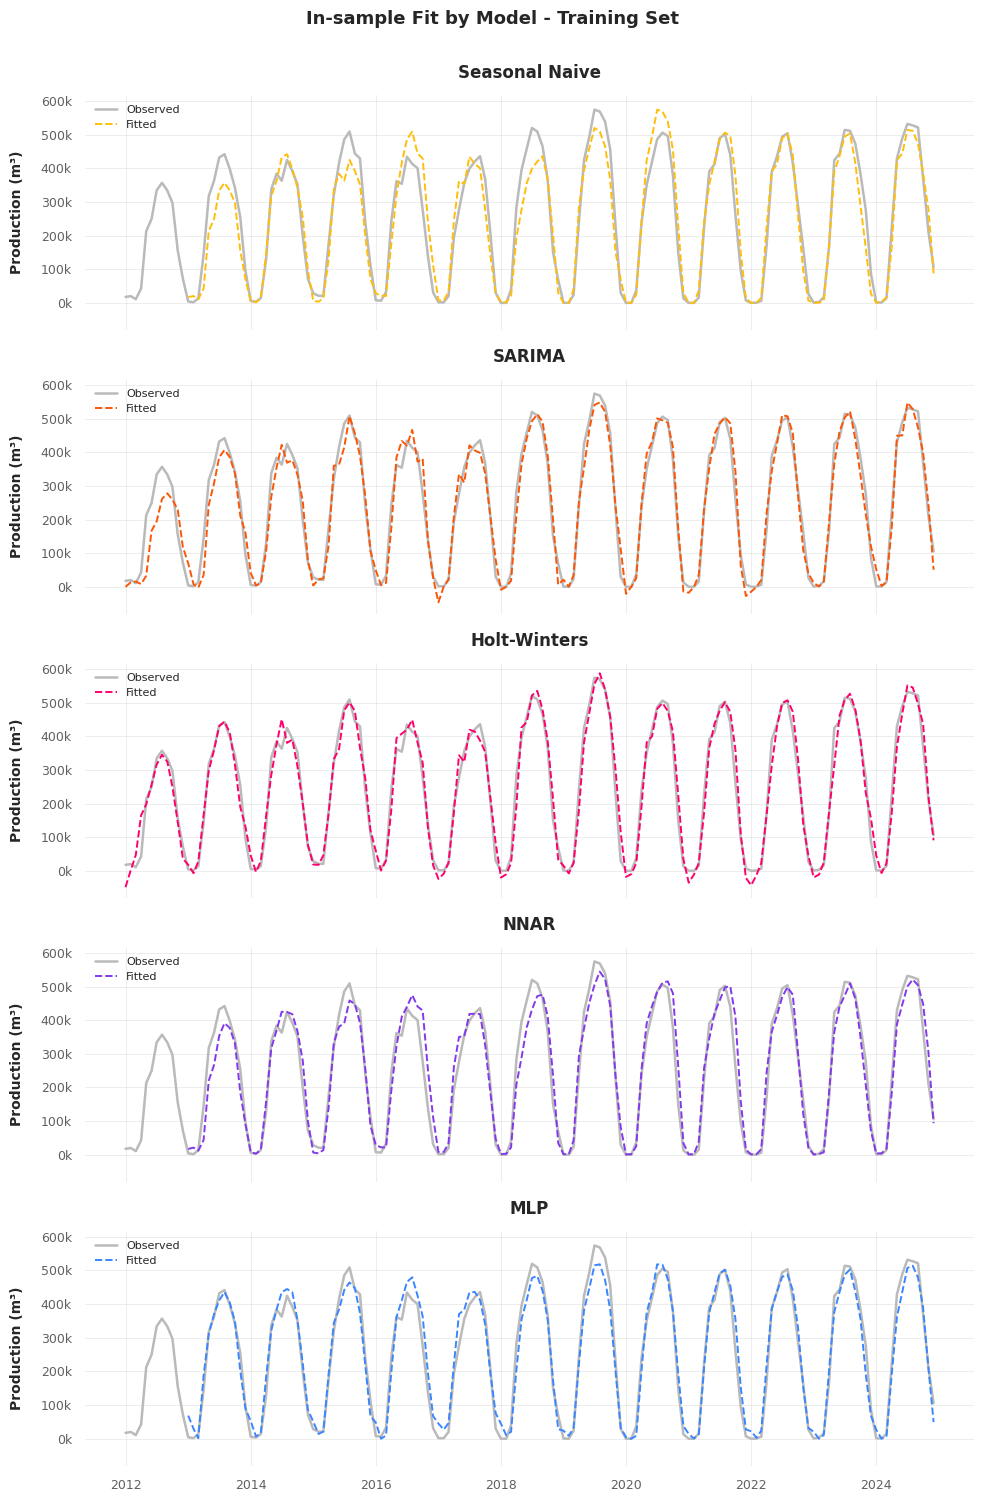

In [ ]:
# ------------------------------------------------------------
# In-sample fit of all models (one panel per model)
# ------------------------------------------------------------

fitted_values = {
    "Seasonal Naive": (snaive_fitted, "#ffbe0b"),
    "SARIMA": (sarima_fitted, "#fb5607"),
    "Holt-Winters": (hw_fitted, "#ff006e"),
    "NNAR": (nnar_fitted, "#8338ec"),
    "MLP": (mlp_fitted, "#3a86ff"),
}

fig, axes = plt.subplots(len(fitted_values), 1, figsize=(10, 15),
                         sharex=True, sharey=True)

for ax, (name, (values, color)) in zip(axes, fitted_values.items()):
    sns.lineplot(x=train.index, y=train.values, ax=ax, linewidth=1.8,
                 color="#BABABA", label="Observed")
    sns.lineplot(x=values.index, y=values.values, ax=ax, linewidth=1.4,
                 linestyle="--", color=color, label="Fitted")

    ax.set_title(name, **title_style)
    ax.set_xlabel("")
    ax.set_ylabel("Production (m³)", **label_style)
    ax.tick_params(axis="both", which="both", **tick_style)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.grid(True, which="major", **grid_style)
    ax.legend(frameon=False, fontsize=8, loc="upper left")

fig.suptitle("In-sample Fit by Model - Training Set", fontsize=13,
             fontweight="semibold", y=1.0)

plt.tight_layout()
plt.show()

## 📊 Model Comparison

Finally, we collect the in-sample fits and the 12-step forecasts from all models, plot them against the observed 2025 values, and summarize accuracy in a single table. The discussion below focuses on which model best captures the harvest-season volume and on the limits all models share in the off-season.

In [ ]:
# ------------------------------------------------------------
# Collect in-sample fits and forecasts
# ------------------------------------------------------------

fitted_all = {
    "Seasonal Naive": snaive_fitted,
    "SARIMA": sarima_fitted,
    "Holt-Winters": hw_fitted,
    "NNAR": nnar_fitted,
    "MLP": mlp_fitted,
}

forecast_all = {
    "Seasonal Naive": snaive_forecast,
    "SARIMA": sarima_forecast,
    "Holt-Winters": hw_forecast,
    "NNAR": nnar_forecast,
    "MLP": mlp_forecast,
}

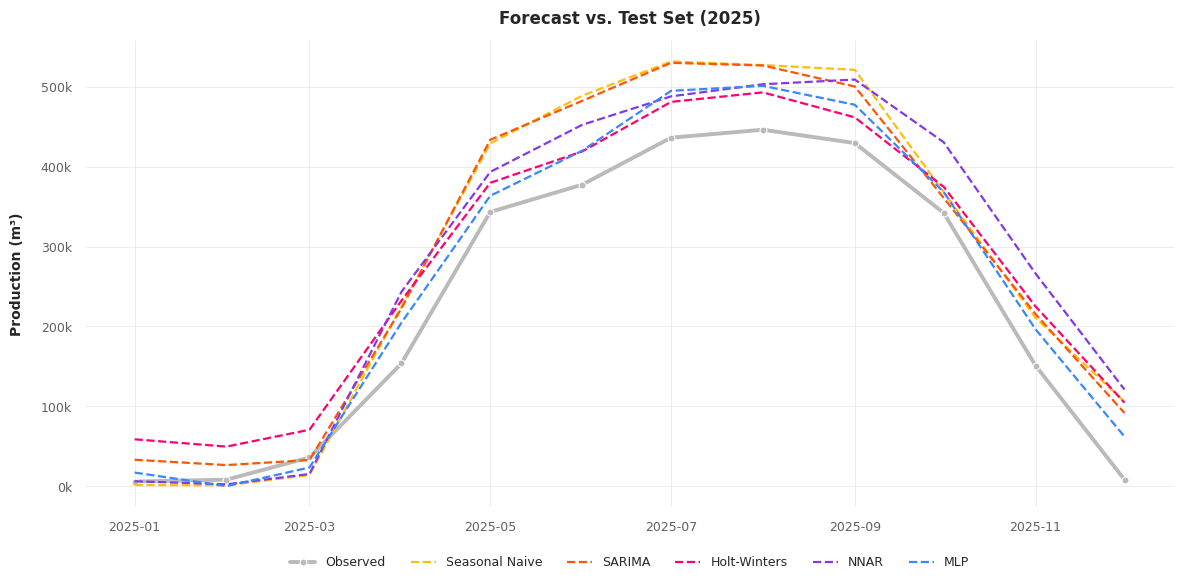

In [ ]:
# ------------------------------------------------------------
# Forecast vs. test set (all models)
# ------------------------------------------------------------

model_colors = {
    "Seasonal Naive": "#ffbe0b",
    "SARIMA": "#fb5607",
    "Holt-Winters": "#ff006e",
    "NNAR": "#8338ec",
    "MLP": "#3a86ff",
}

fig, ax = plt.subplots(figsize=(12, 6))

# Observed test set
sns.lineplot(x=test.index, y=test.values, ax=ax, linewidth=2.8,
             color="#BABABA", marker="o", markersize=5, label="Observed")

# Forecasts
for name, fc in forecast_all.items():
    sns.lineplot(x=fc.index, y=fc.values, ax=ax, linewidth=1.6,
                 linestyle="--", color=model_colors[name], label=name)

ax.set_title("Forecast vs. Test Set (2025)", **title_style)
ax.set_xlabel("")
ax.set_ylabel("Production (m³)", **label_style)
ax.tick_params(axis="both", which="both", **tick_style)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(True, which="major", **grid_style)
ax.legend(frameon=False, fontsize=9, ncol=6, loc="upper center", bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# Model comparison: accuracy metrics
# ------------------------------------------------------------
# RMSE and sMAPE for in-sample fit and 12-step forecast.
# RelRMSE = RMSE / RMSE(Seasonal Naive) on the forecast: indicates
# whether a model beats the naive baseline (RelRMSE < 1).
# sMAPE replaces MAPE because off-season near-zero months make MAPE diverge.

def rmse(actual, forecast):
    return np.sqrt(np.mean((actual - forecast) ** 2))

def smape(actual, forecast):
    denom = (np.abs(actual) + np.abs(forecast)) / 2
    mask = denom != 0
    return np.mean(np.abs(actual[mask] - forecast[mask]) / denom[mask]) * 100

rmse_naive = rmse(test.values, forecast_all["Seasonal Naive"].values)

rows = []
for name in fitted_all:
    fit = fitted_all[name]
    fit_actual = train.loc[fit.index]
    fc = forecast_all[name]
    rows.append({
        "Model": name,
        "RMSE (Fit)": rmse(fit_actual.values, fit.values),
        "sMAPE (Fit)": smape(fit_actual.values, fit.values),
        "RMSE (Forecast)": rmse(test.values, fc.values),
        "sMAPE (Forecast)": smape(test.values, fc.values),
        "RelRMSE (Forecast)": rmse(test.values, fc.values) / rmse_naive,
    })

metrics_table = pd.DataFrame(rows).set_index("Model")
metrics_table.round(2)

,RMSE (Fit),sMAPE (Fit),RMSE (Forecast),sMAPE (Forecast),RelRMSE (Forecast)
Model,,,,,
Seasonal Naive,53518.72,43.21,72589.08,60.43,1.00
SARIMA,42608.04,46.39,68800.66,49.91,0.95
Holt-Winters,36192.78,46.62,54812.57,56.75,0.76
NNAR,46490.00,39.97,72318.66,47.46,1.00
MLP,35104.13,44.23,40406.03,50.64,0.56


# ✅ Results

### Discussion

The metrics tell a consistent story across fit and forecast. The **MLP** is the best model on both, with a forecast RMSE of ~40,400 m³ and a RelRMSE of 0.56 — roughly a 44% reduction in absolute error over the Seasonal Naïve baseline. It captures the harvest-season volume, which dominates total production, more accurately than any other model. **Holt-Winters** is second (RelRMSE 0.76), followed by **SARIMA** (0.95). The **NNAR**, despite its complexity, fails to beat the naive baseline on the forecast (RelRMSE ≈ 1.00) — a useful reminder that sophistication does not guarantee accuracy.

A clear divergence appears between RMSE and sMAPE: by sMAPE the NNAR looks competitive, because that percentage error is inflated by the near-zero off-season months, where small absolute errors become huge in relative terms. RMSE, dominated by the high-volume harvest months, is the more reliable guide for this series. This is why **no model forecasts the off-season well** — the sMAPE values stay high for all of them — yet the ranking by RMSE remains meaningful.

Finally, all trend-extrapolating models were penalized because **2025 did not confirm the upward trend** estimated on the training set: the harvest came in below what the ~5%/year growth would project. This explains why the models systematically overshot the observed 2025 values, especially in the low-production months. For short-term forecasting of this series, a non-linear model with explicit seasonality (MLP) proved the most adequate among the alternatives considered.